In [1]:
import numpy as np
import matplotlib.pyplot as plt
from metpy.calc import parcel_profile, cape_cin
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import add_metpy_logo, SkewT
import pandas as pd

In [2]:
df=pd.read_csv('atmospheric_profile.csv')

In [3]:
df

,Pressure_hPa,Temperature_C,DewPoint_C
0,1000,30.0,22.0
1,975,28.5,20.5
2,950,28.0,19.0
3,925,27.5,17.5
4,900,26.0,15.0
5,875,22.0,12.0
6,850,20.0,9.0
7,825,18.0,6.5
8,800,13.0,4.0
9,775,11.0,2.0


In [4]:
# Convertir perfiles a objetos de metpy
pressure = df.Pressure_hPa * units.hPa
temperature = df.Temperature_C* units.degC
dewpoint = df.DewPoint_C * units.degC

In [5]:
# Define surface temperature and dewpoint
surface_temp = temperature[0]
surface_dewpoint = dewpoint[0]

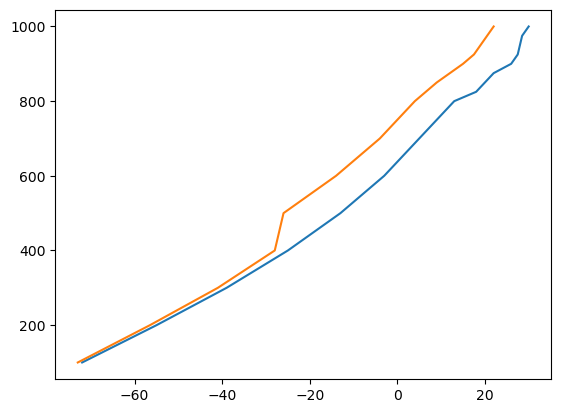

In [6]:
plt.plot(temperature,pressure)
plt.plot(dewpoint,pressure)

In [7]:
# Step 1: Plot initial Skew-T with profile
def plot_initial_profile():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig)

    # Plot temperature and dewpoint
    skew.plot(pressure, temperature, 'r', label='Temperature')
    skew.plot(pressure, dewpoint, 'g', label='Dewpoint')

    # Add title and labels
    plt.title("Step 1: Initial Temperature and Dewpoint Profile")
    plt.legend(loc='upper right')
    plt.show()

# Step 2: Plot lifted parcel path
def plot_lifted_parcel():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig)

    # Plot temperature and dewpoint
    skew.plot(pressure, temperature, 'r', label='Temperature')
    skew.plot(pressure, dewpoint, 'g', label='Dewpoint')

    # Calculate parcel profile and plot
    parcel_prof = parcel_profile(pressure, surface_temp, surface_dewpoint).to('degC')
    skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Parcel Path')

    # Add title and labels
    plt.title("Step 2: Lifted Parcel Path")
    plt.legend(loc='upper right')
    plt.show()

# Step 3: Highlight CAPE and CIN
def plot_cape_cin():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig)

    # Plot temperature and dewpoint
    skew.plot(pressure, temperature, 'r', label='Temperature')
    skew.plot(pressure, dewpoint, 'g', label='Dewpoint')

    # Calculate parcel profile
    parcel_prof = parcel_profile(pressure, surface_temp, surface_dewpoint).to('degC')
    skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Parcel Path')

    # Calculate CAPE and CIN
    cape, cin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)

    # Add annotations for CAPE and CIN
    skew.ax.annotate(f'CAPE: {cape.magnitude:.2f} J/kg', xy=(0.75, 0.25), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='none'))
    skew.ax.annotate(f'CIN: {cin.magnitude:.2f} J/kg', xy=(0.75, 0.20), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='none'))

    # Add title and labels
    plt.title("Step 3: CAPE and CIN Calculation")
    plt.legend(loc='upper right')
    plt.show()

# Sequential plotting function
def plot_steps():
    plot_initial_profile()   # Step 1: Initial profile
    plot_lifted_parcel()     # Step 2: Parcel path
    plot_cape_cin()          # Step 3: CAPE and CIN

# Run the function to display each step



(-10.0, 40.0)

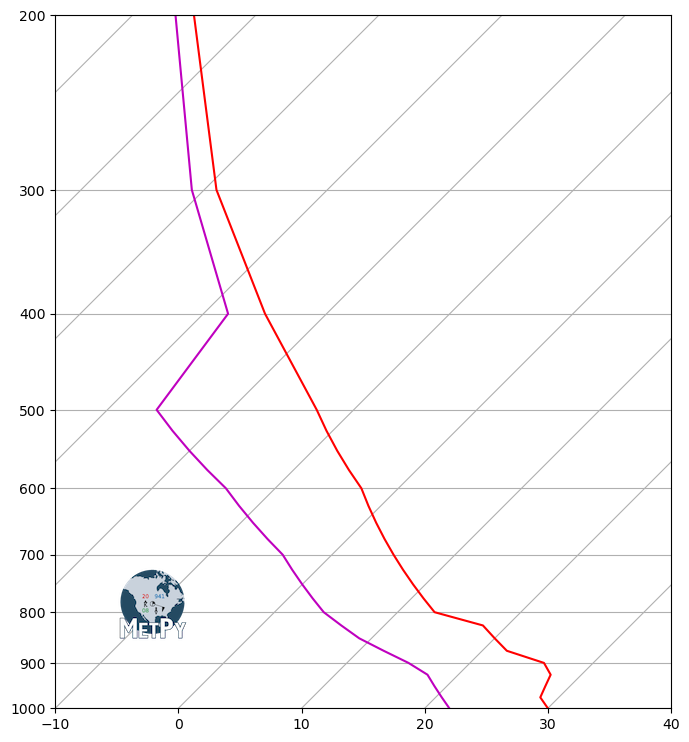

In [8]:
# Crear una figura de tamaño 9x9 pulgadas para la gráfica.
fig = plt.figure(figsize=(9, 9))

# Agregar el logotipo de MetPy a la figura para la personalización y presentación de la gráfica.
add_metpy_logo(fig, 115, 100)

# Crear un gráfico Skew-T, que es una representación típica de un sondeo atmosférico.
# La rotación de 45 grados es el ajuste estándar para inclinar las isobaras (líneas de presión).
skew = SkewT(fig, rotation=45)

# Graficar los datos en la figura, comenzando con las líneas de temperatura y punto de rocío.

# Graficar el perfil de temperatura (T) en función de la presión (p), usando una línea roja ('r').
# El eje Y tiene una escala logarítmica, como es típico en los gráficos meteorológicos,
# ya que la presión atmosférica decrece exponencialmente con la altura.
skew.plot(pressure, temperature, 'r')

# Graficar el perfil del punto de rocío (Td) en función de la presión (p), con una línea verde ('g').
skew.plot(pressure, dewpoint, 'm')

# Graficar las barbas de viento, que representan la velocidad y dirección del viento
# a diferentes niveles de presión (alturas), usando los valores de las componentes u y v del viento.
#skew.plot_barbs(p, u, v)

# Configurar los límites del eje Y para que la gráfica abarque desde 1000 hPa hasta 100 hPa,
# es decir, desde la superficie hasta los niveles superiores de la atmósfera.
skew.ax.set_ylim(1000, 200)

# Configurar los límites del eje X, para que la temperatura en la gráfica oscile entre -40°C y 60°C.
skew.ax.set_xlim(-10, 40)

In [9]:
lcl_pressure, lcl_temperature = mpcalc.lcl(pressure[0]*units.hPa, temperature[0]*units.degC, dewpoint[0]*units.degC)

In [10]:
print('El nivel de condensacion por elevacion LCL se encuentra en: ',lcl_pressure,lcl_temperature)

El nivel de condensacion por elevacion LCL se encuentra en:  890.4181146534693 hectopascal 20.11204214932519 degree_Celsius


In [11]:
lfc_pressure, lfc_temperature = mpcalc.lfc(pressure.values*units.hPa, temperature.values*units.degC, dewpoint.values*units.degC)

In [12]:
print('El nivel de conveccion libre se encuentra en: ',lfc_pressure,lfc_temperature)

El nivel de conveccion libre se encuentra en:  821.4955601118531 hectopascal 17.308315887466566 degree_Celsius


In [13]:
cape=mpcalc.cape_cin(pressure.values*units.hPa, temperature.values* units.degC, dewpoint.values* units.degC,prof)

NameError: name 'prof' is not defined

In [ ]:
fig = plt.figure(figsize=(9, 9))
add_metpy_logo(fig, 115, 100)
skew = SkewT(fig, rotation=45)

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot.
skew.plot(pressure, temperature, 'r',label='Temperatura')
skew.plot(pressure, dewpoint, 'm',label='Temperatura de rocio')
skew.ax.set_ylim(1000, 500)
skew.ax.set_xlim(-10, 40)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature (deg C)')
skew.ax.set_ylabel(f'Pressure (hPa)')

# Calculate LCL height and plot as black dot. Because `p`'s first value is
# ~1000 mb and its last value is ~250 mb, the `0` index is selected for
# `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
# i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
# should be selected.

skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black',label='LCL')

# Calculate full parcel profile and add to plot as black line
prof = mpcalc.parcel_profile(pressure.values*units.hPa, temperature.values[0]* units.degC, dewpoint.values[0]* units.degC).to('degC')
skew.plot(pressure, prof, 'k', linewidth=2,label='Parcela')
skew.plot(lfc_pressure,lfc_temperature,c='navy',marker='s',label='LFC')

skew.ax.legend()

# An example of a slanted line at constant T -- in this case the 0
# isotherm
skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()

In [ ]:
fig = plt.figure(figsize=(9, 9))
add_metpy_logo(fig, 115, 100)
skew = SkewT(fig, rotation=45)

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot.
skew.plot(pressure, temperature, 'r',label='Temperatura')
skew.plot(pressure, dewpoint, 'm',label='Temperatura de rocio')
skew.ax.set_ylim(1000, 200)
skew.ax.set_xlim(-20, 40)

# Set some better labels than the default
skew.ax.set_xlabel(f'Temperature (deg C)')
skew.ax.set_ylabel(f'Pressure (hPa)')

# Calculate LCL height and plot as black dot. Because `p`'s first value is
# ~1000 mb and its last value is ~250 mb, the `0` index is selected for
# `p`, `T`, and `Td` to lift the parcel from the surface. If `p` was inverted,
# i.e. start from low value, 250 mb, to a high value, 1000 mb, the `-1` index
# should be selected.

skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black',label='LCL')

# Calculate full parcel profile and add to plot as black line
prof = mpcalc.parcel_profile(pressure.values*units.hPa, temperature.values[0]* units.degC, dewpoint.values[0]* units.degC).to('degC')
skew.plot(pressure, prof, 'k', linewidth=2,label='Parcela')
skew.plot(lfc_pressure,lfc_temperature,c='dodgerblue',marker='s',label='LFC')
skew.shade_cape(pressure.values*units.hPa, temperature.values* units.degC, prof)
# Add nice text box with calculated values
textstr = '─ Resultados del perfil ─\n\n'
textstr += f'CAPE: {cape[0].magnitude:>8.1f} J/kg\n'
textstr += f'CIN:  {cape[1].magnitude:>8.1f} J/kg\n\n'
textstr += '─ Niveles importantes ─\n\n'
if lcl_pressure:
    textstr += f'LCL:  {lcl_pressure.magnitude:>8.1f} hPa\n'
if lfc_pressure:
    textstr += f'LFC:  {lfc_pressure.magnitude:>8.1f} hPa\n'

props = dict(boxstyle='round,pad=0.8', facecolor='lightblue', 
             edgecolor='darkblue', linewidth=2, alpha=0.95)
skew.ax.text(0.70, 0.97, textstr, transform=skew.ax.transAxes, 
             fontsize=10, verticalalignment='top', bbox=props, 
             fontfamily='monospace', fontweight='bold')
# Shade areas of CAPE and CIN
skew.shade_cin(pressure.values*units.hPa, temperature.values* units.degC, prof)
skew.ax.legend()
# An example of a slanted line at constant T -- in this case the 0
# isotherm
skew.ax.axvline(0, color='c', linestyle='--', linewidth=2)

# Add the relevant special lines
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()